# 1 - Introduction
Online news reaches large audiences, but predicting which articles will become popular is difficult. Two articles that look similar can receive very different levels of engagement, suggesting that popularity depends on many small factors rather than one clear cause.

In this project, we use the [Online News Popularity dataset](https://archive.ics.uci.edu/dataset/332/online+news+popularity) from the UCI Machine Learning Repository to explore whether article popularity—measured by social media shares—can be predicted with basic machine learning models. The dataset includes nearly 40,000 articles with features describing writing style, sentiment, topic, and publication details.

Our walks through the full workflow: data cleaning, exploratory data analysis, model building (Linear Regression, Ridge, and Lasso), and evaluation using RMSE and MAE. Our goal is to understand which features matter most and how well simple models can predict engagement.

# 2 - Data Cleaning
We began by loading the dataset and merging the feature matrix and target into a single DataFrame. We cleaned column names to remove stray whitespace and dropped the non-predictive `url` and `timedelta` fields. Duplicate rows were removed to prevent repeated observations from biasing the model. Because the `shares` variable is extremely right-skewed, we applied a log transformation (`log_shares = log(1 + shares)`) to stabilize variance and make the target more suitable for linear modeling. The cleaned dataset was then saved as a CSV file.

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import os
  
# Fetch dataset 
online_news_popularity = fetch_ucirepo(id=332) 
  
X = online_news_popularity.data.features 
y = online_news_popularity.data.targets 
df = pd.concat([X, y], axis=1)

# Clean column names
df.columns = df.columns.str.strip()
  
# Drop non-predictive columns
cols_to_drop = ["url", "timedelta"]
df = df.drop(columns=cols_to_drop, errors="ignore")

# Remove duplicates
df = df.drop_duplicates()

df["log_shares"] = np.log1p(df["shares"])

output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

df.to_csv(f"{output_dir}/online_news_cleaned.csv", index=False)

df = pd.read_csv("data/online_news_cleaned.csv")
df.head()

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,6.386879
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,6.568078
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,7.313887
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,7.090910
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,6.226537


# 3 - EDA

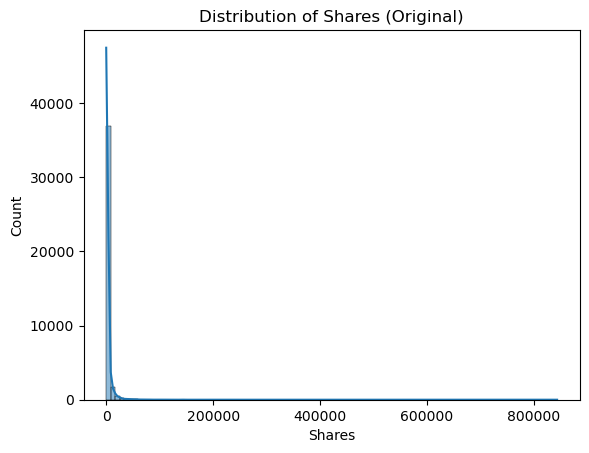

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["shares"], bins=100, kde=True)
plt.title("Distribution of Shares (Original)")
plt.xlabel("Shares")
plt.show()

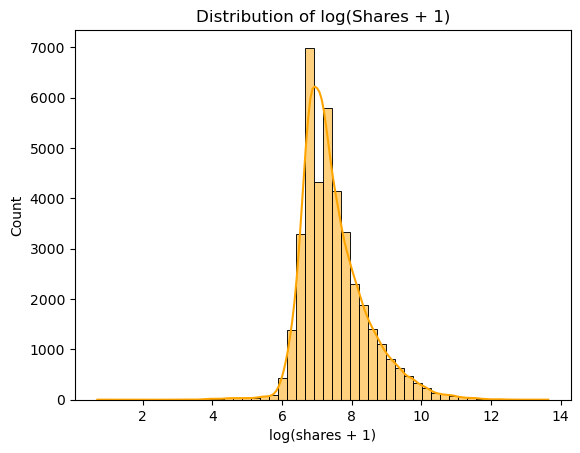

In [3]:
sns.histplot(df["log_shares"], bins=50, kde=True, color="orange")
plt.title("Distribution of log(Shares + 1)")
plt.xlabel("log(shares + 1)")
plt.show()

The first plot shows that shares are extremely right-skewed: most articles receive very few shares, while a small number go viral and reach very high values. This makes the raw target hard for regression models to learn from because outliers dominate the scale. After applying a log(1 + shares) transformation, the second plot becomes much more balanced and roughly bell-shaped. This reduces the impact of extreme values, makes the target easier to model, and typically improves both stability and accuracy for linear models.

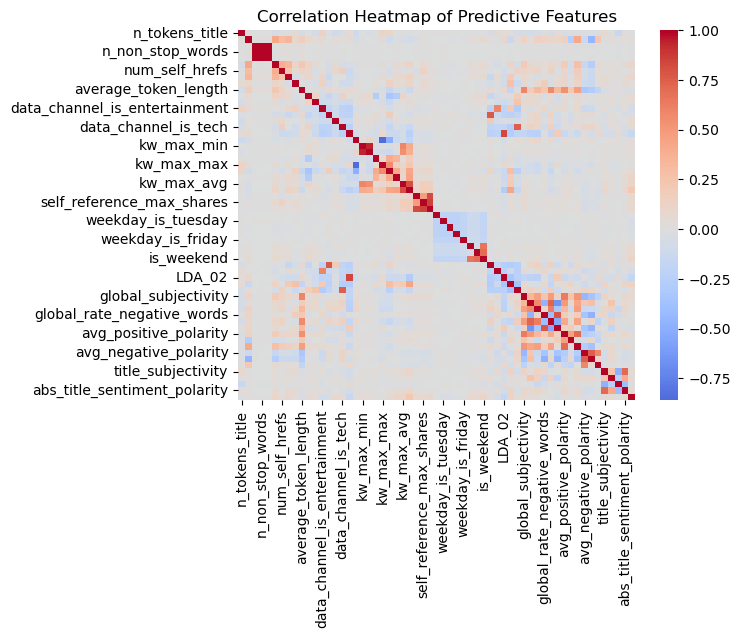

In [4]:
corr = df.drop(columns=["shares"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Predictive Features")
plt.show()

The heatmap shows that most features have very weak correlations with one another and with the target. Only the keyword-based features show some clustering, meaning they are moderately related. Overall, there are no strong linear predictors, and the dataset is noisy and high-dimensional. Because of this, models like Ridge and Lasso are useful since they handle weak signals and feature overlap better than ordinary linear regression.

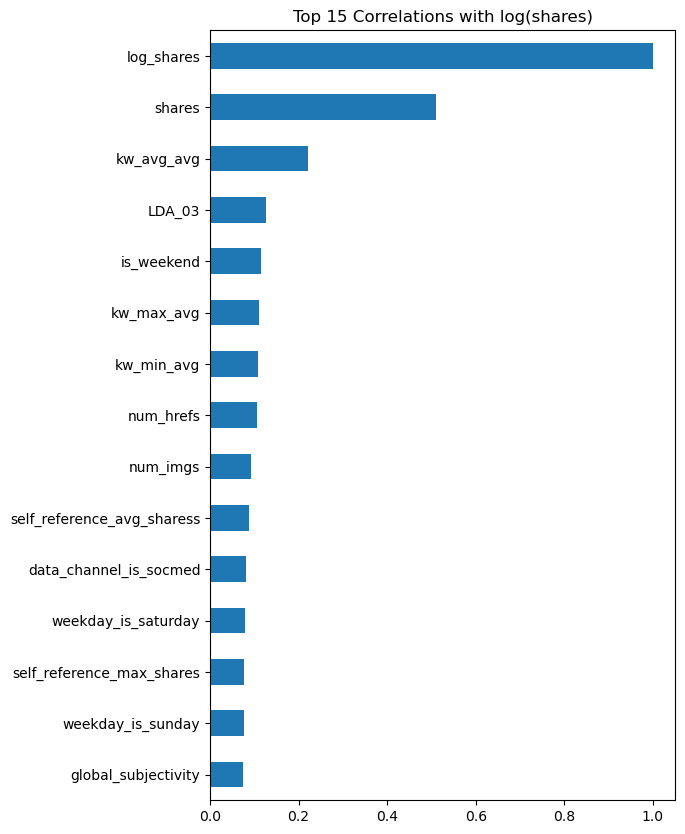

In [5]:
target_corr = df.corr()["log_shares"].sort_values(ascending=False)
plt.figure(figsize=(6,10))
target_corr.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Correlations with log(shares)")
plt.show()

This bar chart shows the top 15 features most correlated with log(shares). Even the strongest predictors have very weak correlations, mostly below 0.15. Overall, the extremely low correlations across all predictors demonstrate that no single feature strongly explains article popularity. Overall, popularity depends on many small effects rather than a few dominant predictors, reinforcing why regularization and multi-feature models are necessary.

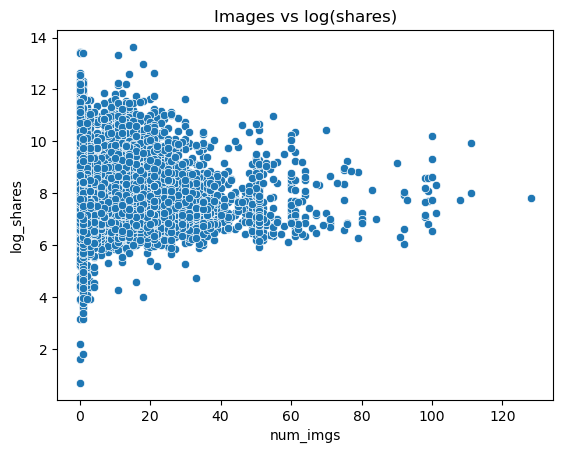

In [6]:
sns.scatterplot(x=df["num_imgs"], y=df["log_shares"])
plt.title("Images vs log(shares)")
plt.show()

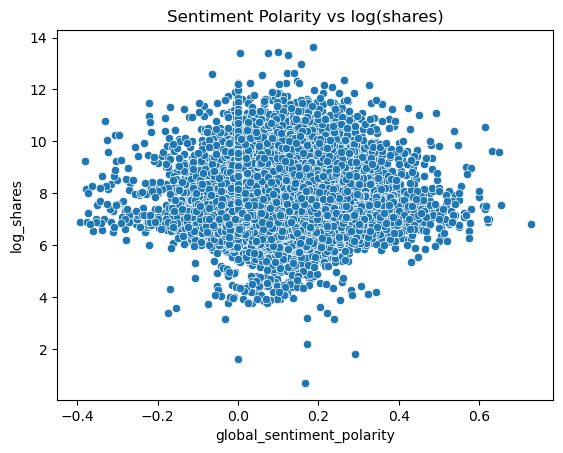

In [7]:
sns.scatterplot(x=df["global_sentiment_polarity"], y=df["log_shares"])
plt.title("Sentiment Polarity vs log(shares)")
plt.show()

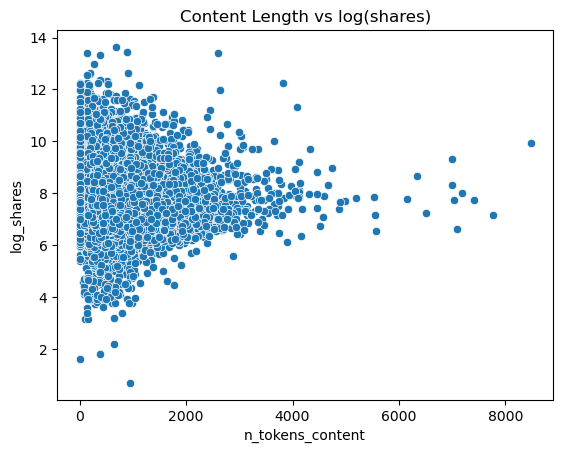

In [8]:
sns.scatterplot(x=df["n_tokens_content"], y=df["log_shares"])
plt.title("Content Length vs log(shares)")
plt.show()

These scatterplots examine three representative features—number of images, sentiment polarity, and content length—against the log-transformed share count. All three plots show very wide dispersion with no clear linear trend, indicating that these features individually have little predictive power for article popularity. Articles with many images, highly positive or negative sentiment, or very long content do not consistently receive more shares. This further supports the conclusion that popularity is driven by many weak signals rather than any single strong feature.

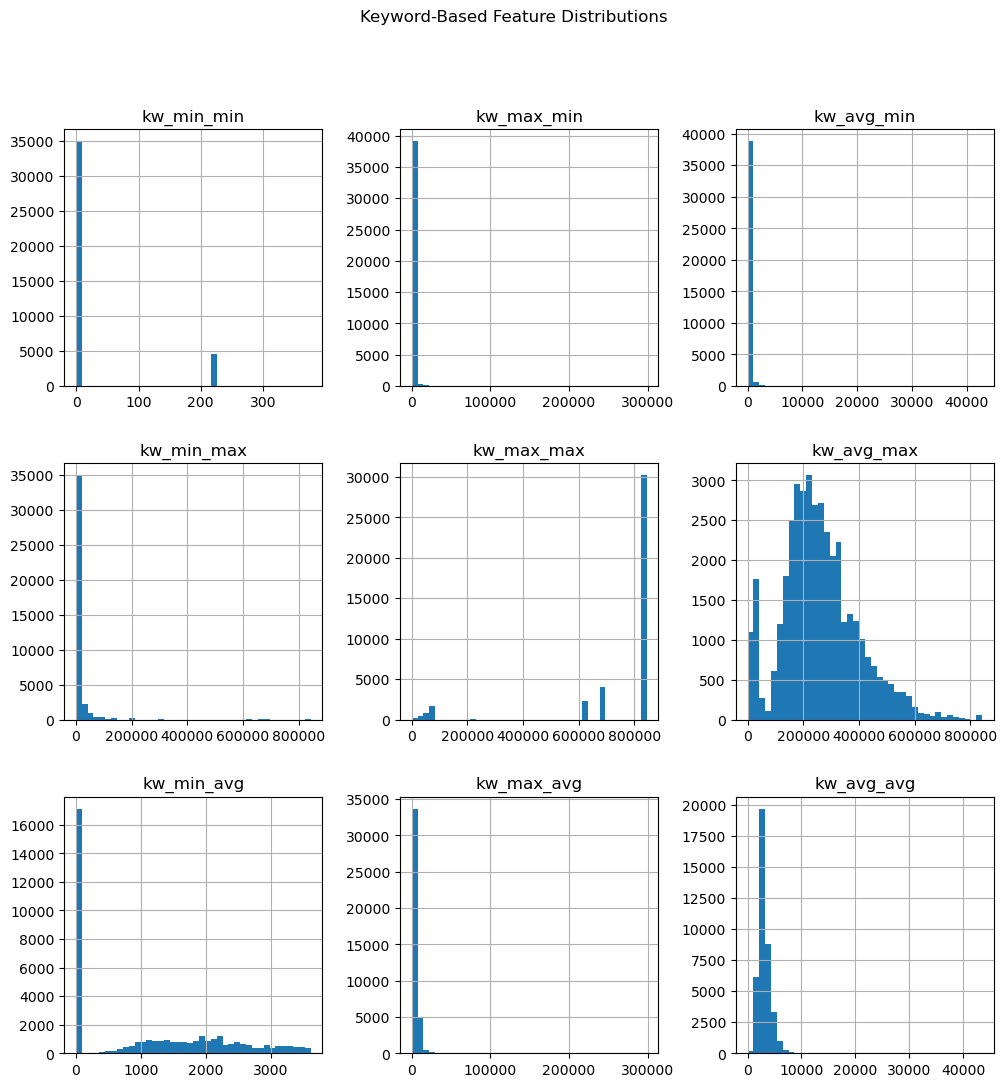

In [9]:
kw_cols = [c for c in df.columns if c.startswith("kw_")]
df[kw_cols].hist(figsize=(12,12), bins=40)
plt.suptitle("Keyword-Based Feature Distributions")
plt.show()

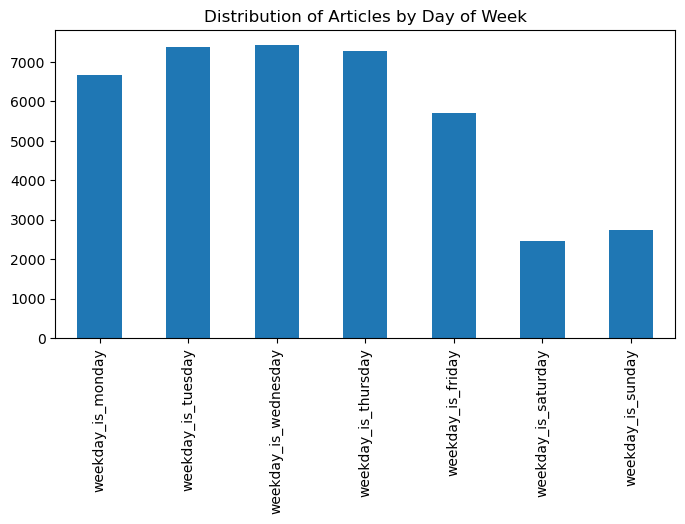

In [10]:
weekday_cols = [c for c in df.columns if c.startswith("weekday_is_")]
df[weekday_cols].sum().plot(kind="bar", figsize=(8,4))
plt.title("Distribution of Articles by Day of Week")
plt.show()

The above two plots (histograms and bar chart) show that keyword features are highly skewed with many extreme outliers. Most articles have very small keyword values, while a few have extremely large ones. This uneven distribution makes the keyword features noisy and reinforces the need for scaling and regularization in the models.

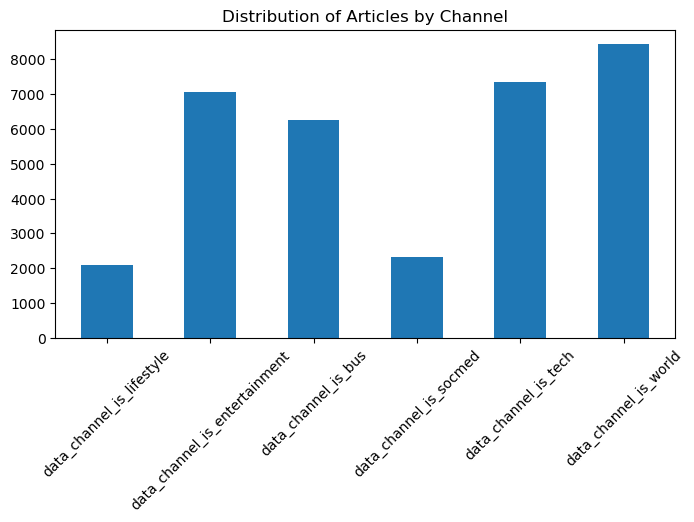

In [11]:
channel_cols = [c for c in df.columns if "data_channel" in c]

df[channel_cols].sum().plot(kind="bar", figsize=(8,4))
plt.title("Distribution of Articles by Channel")
plt.xticks(rotation=45)
plt.show()

This plot shows how often articles appear in each content channel. Most articles come from the World, Tech, and Entertainment sections, while categories like Lifestyle and Social Media have far fewer posts. Later analysis shows that channel alone has only a small effect on how widely an article is shared.

## Summary
The dataset contains 39,644 articles and 58 numeric features related to content structure, keywords, sentiment, topics, and publication timing. There are no missing values, and all columns are in a modeling-friendly format.

The target variable shares is extremely right-skewed, so using the log-transformed version (log_shares) gives a more stable distribution for regression.

Most features show very high variance and strong skew, especially keyword-based variables, which contain extreme outliers. This confirms the need for scaling and regularization.

Correlation analysis shows that no single feature strongly predicts popularity. All correlations with log_shares are weak (mostly under 0.15).

Distribution plots of weekday and channel variables reveal that there are far more article publishes on weekdays and in certain categories (World, Tech, Entertainment), but these patterns do not translate into meaningful predictive power.

Overall, the dataset is high-dimensional and noisy, with many weak predictors rather than a few strong ones. Effective modeling therefore requires standardization, regularization (Ridge/Lasso), and careful validation to prevent overfitting.

# 3 - Modeling


In [13]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# Set seed
np.random.seed(42)

# Load data
df = pd.read_csv("data/online_news_cleaned.csv")

# Prepare features and target
y = df["log_shares"].to_numpy()
X = df.drop(columns=["shares", "log_shares"])
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns
X = X.to_numpy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Fit PCA on training data
pca = PCA(n_components=0.95)
pca.fit(X_train)

# Transform training and test sets
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Train PCA-based Linear Regression
lr_pca = LinearRegression()
lr_pca.fit(X_train_pca, y_train)

# Predict
y_pred_pca = lr_pca.predict(X_test_pca)

# Evaluate
pca_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pca))
pca_mae  = mean_absolute_error(y_test, y_pred_pca)

print("PCA Linear Regression RMSE:", pca_rmse)
print("PCA Linear Regression MAE:", pca_mae)

PCA Linear Regression RMSE: 0.877641061106924
PCA Linear Regression MAE: 0.6550423079755157


The PCA Linear Regression model produced an RMSE of 0.8776 and an MAE of 0.6550, showing that the reduced feature space captures only part of the variation needed to predict article popularity. Because PCA compresses many original features into a smaller set of components, some useful information is lost. These results suggest that article popularity depends on many small signals across the full feature set, and reducing dimensionality makes it harder for the model to predict accurately.

In [14]:
# Train and evaluate Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

Linear Regression RMSE: 0.8648576034715385
Linear Regression MAE: 0.6439770979847044


Best Ridge alpha: 483.2930238571752
Ridge RMSE: 0.8657065300119323
Ridge MAE: 0.6450126958075492

Top 20 Feature Importances:
kw_avg_avg                       0.346167
kw_max_avg                      -0.184296
data_channel_is_entertainment   -0.071889
LDA_00                           0.065922
kw_min_min                       0.059840
LDA_02                          -0.057167
average_token_length            -0.056818
data_channel_is_bus             -0.056503
global_subjectivity              0.051224
num_hrefs                        0.049280
data_channel_is_socmed           0.043346
is_weekend                       0.042171
data_channel_is_tech             0.041047
kw_avg_min                      -0.040166
kw_min_avg                      -0.035079
num_self_hrefs                  -0.033965
self_reference_min_shares        0.030685
weekday_is_saturday              0.030049
num_imgs                         0.029838
abs_title_subjectivity           0.029638
dtype: float64


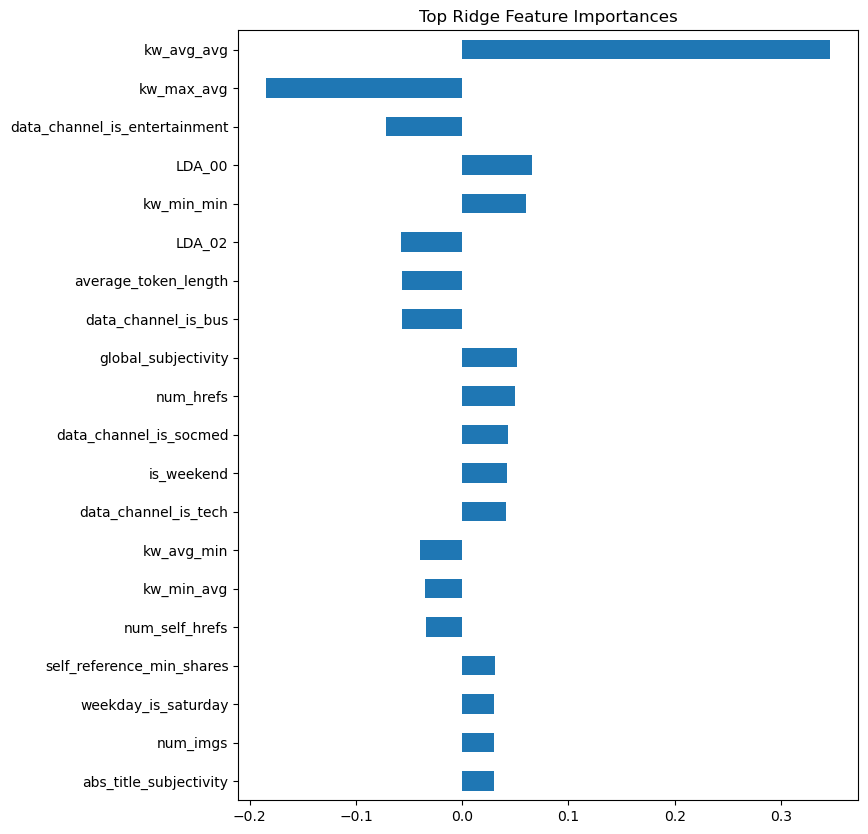

In [15]:
from sklearn.linear_model import Ridge

# Train and evaluate Ridge Regression with hyperparameter tuning
alphas = np.logspace(-3, 3, 20)
ridge = Ridge()

# Set up GridSearchCV to find the best alpha
ridge_cv = GridSearchCV(
    ridge,
    {"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_cv.fit(X_train, y_train)

best_ridge_alpha = ridge_cv.best_params_["alpha"]
print("Best Ridge alpha:", best_ridge_alpha)

# Train Ridge with the best alpha
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train, y_train)

y_pred_ridge = ridge_best.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)

# Feature importance for Ridge
coef = ridge_best.coef_
importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.head(20).plot(kind="barh", figsize=(8,10))
plt.title("Top Ridge Feature Importances")
plt.gca().invert_yaxis()
plt.show()

Ridge regression shows that keyword features (kw_avg_avg, kw_max_avg) are the strongest predictors of popularity, meaning articles tied to broadly used or popular keywords tend to get more shares. A few topic (LDA) features and basic content features (like average_token_length and num_hrefs) also matter, but only slightly. Channel and timing indicators (e.g., entertainment, weekend) show small effects as well.

The overall takeaway is that no single feature strongly predicts popularity. Ridge works by combining many weak signals, which fits a dataset that is noisy and highly variable.

Best Lasso alpha: 0.001
Lasso RMSE: 0.8648404133813664
Lasso MAE: 0.644119268368759


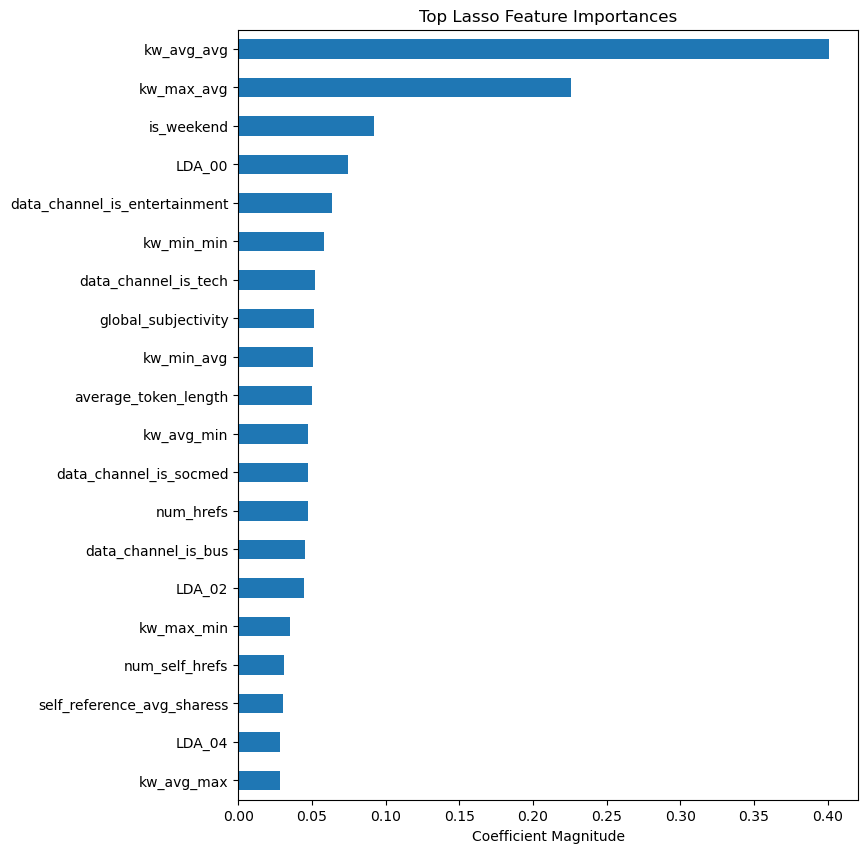

In [16]:
from sklearn.linear_model import Lasso

# Train and evaluate Lasso Regression with hyperparameter tuning
lasso = Lasso(max_iter=5000)

# Set up GridSearchCV to find the best alpha
lasso_cv = GridSearchCV(
    lasso,
    {"alpha": alphas},
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_cv.fit(X_train, y_train)

best_lasso_alpha = lasso_cv.best_params_["alpha"]
print("Best Lasso alpha:", best_lasso_alpha)

# Fit final Lasso model with best alpha
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_best.fit(X_train, y_train)

y_pred_lasso = lasso_best.predict(X_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso RMSE:", lasso_rmse)
print("Lasso MAE:", lasso_mae)

# Feature importance for Lasso
lasso_coef = pd.Series(lasso_best.coef_, index=feature_names)
top_lasso = lasso_coef.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(8,10))
top_lasso.sort_values().plot(kind="barh")
plt.title("Top Lasso Feature Importances")
plt.xlabel("Coefficient Magnitude")
plt.show()

Lasso highlights a small set of features that matter most for predicting article popularity. The strongest predictors are keyword-related features (kw_avg_avg, kw_max_avg), meaning articles associated with highly-used or high-impact keywords tend to receive more shares. Lasso also selects a few additional signals—such as whether the article was published on a weekend, certain topic components (LDA_00), and specific publication channels (Entertainment, Tech).

Because Lasso forces many coefficients to zero, it confirms that only a handful of features carry meaningful predictive power, while most others contribute very little. This reinforces the idea seen throughout the EDA: article popularity is driven by many small effects, but keyword metrics consistently stand out as the most influential.

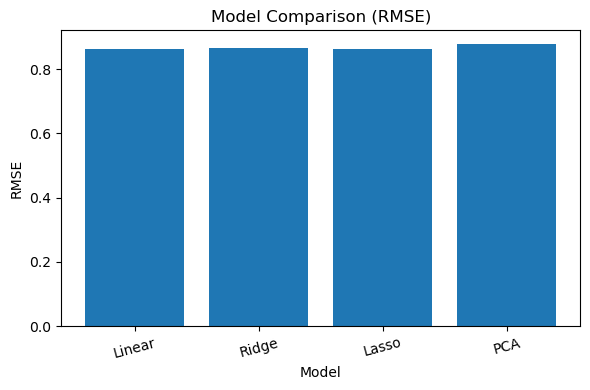

In [17]:
# Summary of results
models = ["Linear", "Ridge", "Lasso", "PCA"]
rmses = [lr_rmse, ridge_rmse, lasso_rmse, pca_rmse]

plt.figure(figsize=(6,4))
plt.bar(models, rmses)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4 - Results
We evaluated four models: a baseline Linear Regression, a tuned Ridge Regression, a tuned Lasso Regression, and a PCA-based Linear Regression. All models were trained on 80% of the dataset and evaluated on a 20% test set using RMSE and MAE as performance metrics.

|Model|RMSE|MAE|
|--:|---:|-------:|
|Linear|0.8649|0.6440|
|Ridge|0.8657|0.6450|
|Lasso|0.8648|0.6441|
|PCA|0.8776|0.6550|

Across the first three models, the results are remarkably similar. Lasso achieved the lowest RMSE, followed closely by Linear and Ridge, indicating that regularization had only a marginal effect on predictive accuracy. PCA resulted in slightly worse performance, suggesting that dimensionality reduction discarded weak but meaningful signals present in the original feature set.

# 5 - Discussion
All three models—Linear, Ridge, and Lasso—performed similarly, showing that no single feature strongly predicts article popularity. Ridge kept all features but reduced their impact, while Lasso kept only the most important ones, like kw_avg_avg, kw_max_avg, LDA_00, and is_weekend. PCA was tested to reduce the number of features, but it actually made the model slightly worse. This suggests that even weak features carry some useful signal that’s lost when compressed. Overall, an RMSE around 0.865 means the models still make big errors in predicting shares, which highlights how hard it is to predict what will go viral.

# 6 - Conclusion
This project used machine learning to predict how popular an article would be based on its content and structure. We found that no single feature explains popularity well—instead, many small and noisy factors play a role. Ridge and Lasso helped reduce overfitting and made models easier to interpret but didn’t improve performance much. PCA didn’t help either, likely because it removed useful details. Overall, predicting article popularity is hard because the data is noisy and patterns are weak. Linear models work okay, but more advanced methods like tree-based models or deep learning might do better.